# Analisi polarimetrica — tesi triennale

Notebook di orchestrazione della pipeline 2D Stokes + retardance per la tesi.
Tutta la logica numerica vive nel package `polarimetro/` (vedi `python/CLAUDE.md`).

**Ordine pipeline** (per ogni canale): caricamento RAW → Stokes lineari (S0/S1/S2) →
S3 dalla lamina λ/4 → maschera bg → allineamento (asse S3 + asse S2 Poincaré) →
DoLP/AoLP → retardance δ in [0°, 360°) e asse veloce θ.

L'esecuzione delle celle è gated dal **dispatcher**: per ciascun dataset solo le
analisi rilevanti vengono eseguite.


## Configurazione globale


In [109]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import matplotlib.pyplot as plt

import polarimetro as pol
from polarimetro import (
    clustering_plot as polcluster,
    config as polcfg,
    dispersion as poldisp,
    photoelasticity as polphoto,
    pipeline as polpipe,
    plotting as polplot,
    slice_fit as polslice,
    umap_runner as polumap,
)

polplot.apply_thesis_style()

# --- parametri di sessione (modificare e re-runnare per cambiare contesto) ---
DATASET = 'lambdamezzi_50deg'
CHANNEL = 'all'           # 'R' | 'G' | 'B' | 'all' (solo display)
DOWNSAMPLE_FACTOR = 4
SAVE_PLOTS = True
OUTPUT_DIR = '../Images/generated'

RUN_SPECTRA = False       # rigenera centroidi RGB (one-shot)
RUN_DEBUGGER = False      # apre debugger pixel-per-pixel

# --- path derivati ---
TARGET_FOLDER = f'./raw/{DATASET}'
POL_SUBFOLDER = os.path.join(TARGET_FOLDER, 'pol')
WAV_SUBFOLDER = os.path.join(TARGET_FOLDER, 'wav')
WAVELENGTHS_CSV = './outputs/rgb_wavelengths.csv'
DARK_FRAME_PATH = './raw/dark.dng'

# CHANNEL è display-only: la pipeline computa SEMPRE i 3 canali RGB,
# solo la visualizzazione PDF/HTML è gated da DISPLAY_CHANNELS.
CHANNELS_RGB = {'R': 0, 'G': 1, 'B': 2}
ACTIVE_CHANNELS = list(CHANNELS_RGB.keys())
DISPLAY_CHANNELS = list(CHANNELS_RGB.keys()) if CHANNEL == 'all' else [CHANNEL]

print(f"dataset={DATASET}, channels={ACTIVE_CHANNELS}, display={DISPLAY_CHANNELS}, "
      f"DS={DOWNSAMPLE_FACTOR}, waveplate_swapped={polcfg.is_waveplate_swapped(TARGET_FOLDER)}")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
dataset=lambdamezzi_50deg, channels=['R', 'G', 'B'], display=['R', 'G', 'B'], DS=4, waveplate_swapped=True


## Dispatcher analisi per dataset

Mappa ogni `DATASET` alle analisi attive (token usati come gate `if 'X' in active_analyses`).


In [ ]:
# Ogni dataset attiva un sottoinsieme di analisi. I token (A, B, C-aolp, ...)
# vengono usati come gate `if 'X' in active_analyses` nelle celle sottostanti.
ANALYSES_PER_DATASET = {
    'strati_v2':          ['A', 'B', 'C-delta', 'F', 'E', 'H'],
    'lambdaquarti_50deg': ['A', 'B', 'C-delta', 'D-delta', 'D-delta-fit'],
    'lambdamezzi_50deg':  ['A', 'B', 'C-delta', 'D-delta', 'D-delta-fit', 'MO'],
    'zucchero':           ['A', 'B', 'C-aolp', 'D-aolp', 'D-aolp-fit'],
    'barraon_v2':         ['A', 'B', 'I'],
    'barraoff_v2':        ['A', 'B'],
    'righello_v2':        ['A', 'B'],
}

active_analyses = ANALYSES_PER_DATASET.get(DATASET, [])
print(f"analisi attive per {DATASET}: {active_analyses}")


## Pipeline Stokes — RAW → S0/S1/S2/S3 + allineamento + retardance

Pass A: lettura RAW polarizzazione + S3 da lamina λ/4 (streaming RGB se
multi-canale). Pass B parallelo per canale: `align_reference_frame` +
`align_poincare_ellipticity` + DoLP/AoLP + δ/θ. Maschera bg unificata da
`mean(S0_RGB)` se più canali attivi. Cache npz in `outputs/stokes_<DATASET>_DS<n>.npz`.


In [111]:
from concurrent.futures import ThreadPoolExecutor

# bg_mask unificata da mean(S0_RGB) quando si processano più canali.
UNIFIED_BG_MASK = len(ACTIVE_CHANNELS) > 1
cache_path = f'./outputs/stokes_{DATASET}_DS{DOWNSAMPLE_FACTOR}.npz'

print(f"=== Load+Stokes: DATASET='{DATASET}', DS={DOWNSAMPLE_FACTOR}, "
      f"channels={ACTIVE_CHANNELS}, unified_mask={UNIFIED_BG_MASK} ===")
print(f"    cache_target = {cache_path}")

stokes_data = {}

if active_analyses:
    os.makedirs('./outputs', exist_ok=True)

    # 1. tentativo di caricamento cache (invalidata su mismatch DS/dataset/unified).
    cached = polpipe.load_cache_npz(
        cache_path, DATASET, DOWNSAMPLE_FACTOR, UNIFIED_BG_MASK,
        ACTIVE_CHANNELS, CHANNELS_RGB)
    if cached is not None:
        stokes_data = cached
    else:
        # 2. reset cache globali (saturation, wav intensity, Poincaré bg mask).
        pol.reset_all_caches()
        ch_idx_list = [CHANNELS_RGB[ch] for ch in ACTIVE_CHANNELS]
        wavelengths_per_ch = {ci: polcfg.get_channel_wavelength(WAVELENGTHS_CSV, ci)
                               for ci in ch_idx_list}

        # 3. Pass A: RAW + Stokes lineari + S3 (streaming RGB se multi-canale).
        if UNIFIED_BG_MASK:
            print("\n=== Pass A: streaming RGB (38 file letti una sola volta) ===")
            raw_per_ch = polpipe.run_pass_a_unified(
                ACTIVE_CHANNELS, CHANNELS_RGB, POL_SUBFOLDER, WAV_SUBFOLDER,
                DOWNSAMPLE_FACTOR, wavelengths_per_ch, DARK_FRAME_PATH,
                invert_angles=True)
            print(f"\n=== bg_mask unificata da mean(S0) su {ACTIVE_CHANNELS} ===")
            bg_mask_shared = polpipe.compute_unified_bg_mask(
                raw_per_ch, ACTIVE_CHANNELS, DOWNSAMPLE_FACTOR)
        else:
            raw_per_ch = polpipe.run_pass_a_per_channel(
                ACTIVE_CHANNELS, CHANNELS_RGB, POL_SUBFOLDER, WAV_SUBFOLDER,
                DOWNSAMPLE_FACTOR, wavelengths_per_ch, DARK_FRAME_PATH,
                invert_angles=True)
            bg_mask_shared = None

        # 4. Pass B: align + retardance per canale in parallelo (thread-safe).
        print(f"\n=== Pass B: align + retardance ({len(ACTIVE_CHANNELS)} thread paralleli) ===")
        with ThreadPoolExecutor(max_workers=len(ACTIVE_CHANNELS)) as ex:
            futures = {ex.submit(polpipe.process_channel, ch, raw_per_ch,
                                  bg_mask_shared, DOWNSAMPLE_FACTOR, TARGET_FOLDER): ch
                       for ch in ACTIVE_CHANNELS}
            for fut in futures:
                ch, result = fut.result()
                stokes_data[ch] = result

        # 5. saturation mask globale OR fra canali (NaN sui pixel clippati).
        sat_mask, n_sat = polpipe.apply_saturation_global(
            stokes_data, ACTIVE_CHANNELS, DOWNSAMPLE_FACTOR)
        if sat_mask is not None and n_sat:
            frac = 100.0 * n_sat / sat_mask.size
            print(f"\nSaturation (global OR): {n_sat} blocchi clippati ({frac:.2f}%)")

        # 6. log sintetico + persistenza npz.
        for ch in ACTIVE_CHANNELS:
            d = stokes_data[ch]
            valid = d['bg_mask'] & np.isfinite(d['delta'])
            if valid.any():
                p5, p50, p95 = np.percentile(d['delta'][valid], [5, 50, 95])
                print(f"  {ch}: S0 shape={d['S0'].shape}  "
                      f"delta_bg pctl [5,50,95]=[{p5:.1f}, {p50:.1f}, {p95:.1f}] deg")

        polpipe.save_cache_npz(cache_path, stokes_data, DATASET,
                                DOWNSAMPLE_FACTOR, UNIFIED_BG_MASK)


=== Load+Stokes: DATASET='lambdamezzi_50deg', DS=4, channels=['R', 'G', 'B'], unified_mask=True ===
    cache_target = ./outputs/stokes_lambdamezzi_50deg_DS4.npz
Cache loaded: ./outputs/stokes_lambdamezzi_50deg_DS4.npz  (dataset='lambdamezzi_50deg', DS=4, unified=True, channels=['R', 'G', 'B'])


## A — Maschera di sfondo (overlay diagnostico)

Visualizza la maschera bg + maschera Poincaré (overlay 3-color: bg utile,
banda XOR del wav-holder, sample). Una sola figura se `unified_mask`,
altrimenti una per canale.


  saved: ../Images/generated\lambdamezzi_50deg\mask.pdf


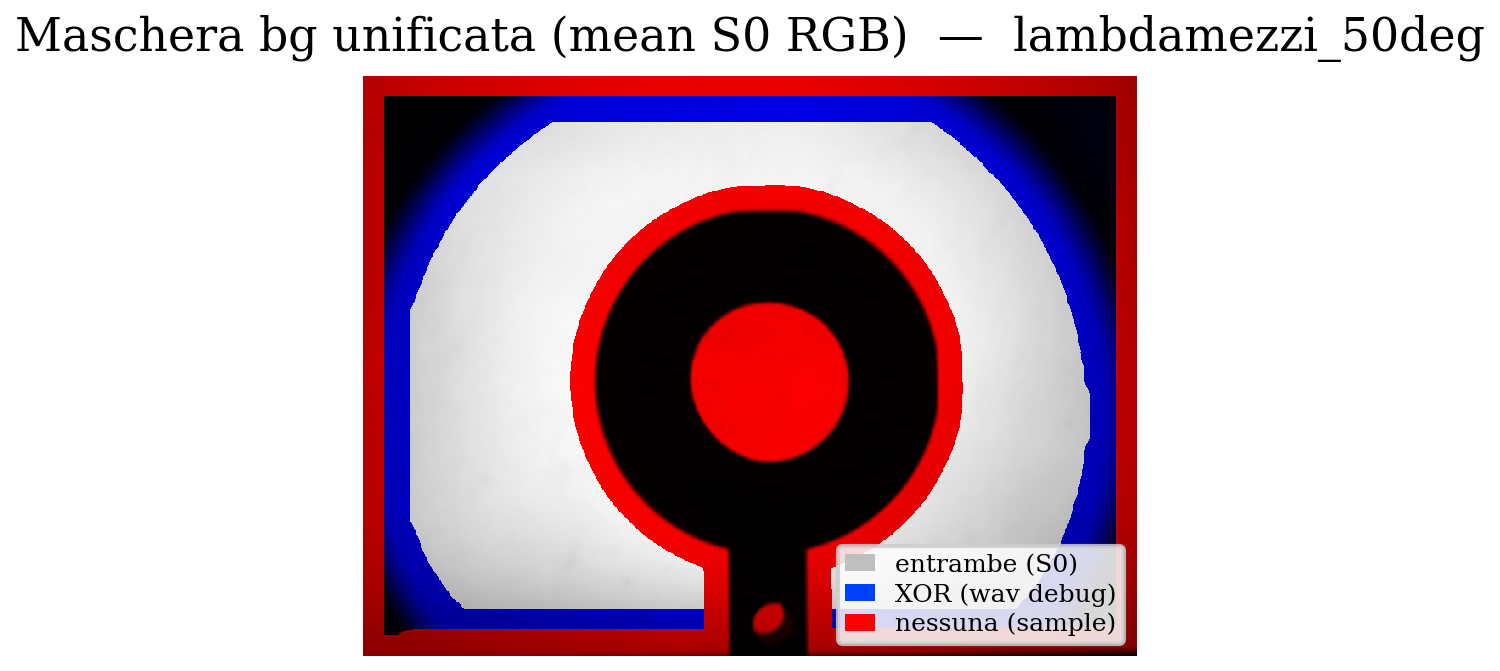

In [112]:
if 'A' in active_analyses and stokes_data:
    out_A = os.path.join(OUTPUT_DIR, DATASET)
    if SAVE_PLOTS:
        os.makedirs(out_A, exist_ok=True)

    # Maschera unificata: stessa bg_mask in tutti i canali (multi-canale + UNIFIED_BG_MASK).
    unified_A = (len(ACTIVE_CHANNELS) > 1
                 and all(np.array_equal(stokes_data[ch]['bg_mask'],
                                          stokes_data[ACTIVE_CHANNELS[0]]['bg_mask'])
                         for ch in ACTIVE_CHANNELS))
    if unified_A:
        S0_mean_A = np.mean(np.stack([stokes_data[ch]['S0']
                                        for ch in ACTIVE_CHANNELS], axis=0), axis=0)
        ref = stokes_data[ACTIVE_CHANNELS[0]]
        wav_mean = (ref['wav_intensity'] / 2.0) if ref['wav_intensity'] is not None else None
        pdf_A = os.path.join(out_A, 'mask.pdf') if SAVE_PLOTS else None
        polplot.plot_mask_overlay_figure(
            S0_mean_A, ref['bg_mask'], ref['poincare_bg_mask'], wav_mean,
            title=f"Maschera bg unificata (mean S0 RGB)  —  {DATASET}",
            out_pdf=pdf_A)
    else:
        for ch in ACTIVE_CHANNELS:
            d = stokes_data[ch]
            wav_mean = (d['wav_intensity'] / 2.0) if d['wav_intensity'] is not None else None
            pdf_A = os.path.join(out_A, f'{ch}_mask.pdf') if SAVE_PLOTS else None
            polplot.plot_mask_overlay_figure(
                d['S0'], d['bg_mask'], d['poincare_bg_mask'], wav_mean,
                title=f"Maschera bg  —  {DATASET}/{ch}",
                out_pdf=pdf_A)


## B — Mappe Stokes + DoLP, AoLP, δ, θ

Esporta le 8 mappe pubblicate (S0, S1, S2, S3, DoLP, AoLP, δ, θ) come PDF +
heatmap plotly interattivi. Configurazione cmap/range centralizzata in
`polarimetro.plotting.STOKES_PARAM_CONFIG`.


  saved: ../Images/generated\lambdamezzi_50deg\R_S0.pdf


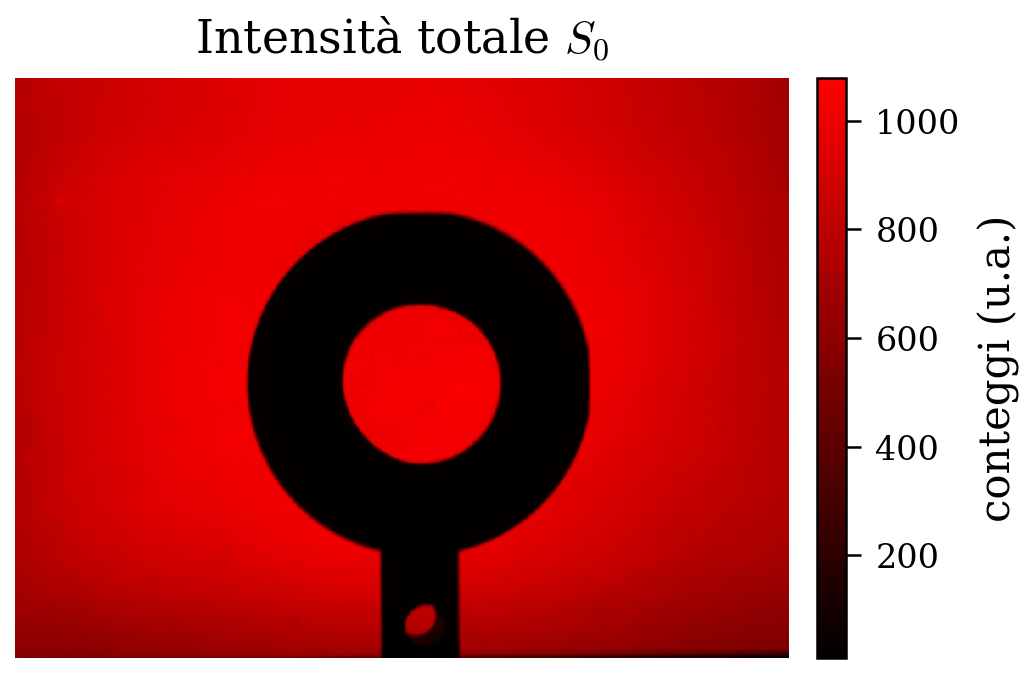

  saved: ../Images/generated\lambdamezzi_50deg\R_S1.pdf


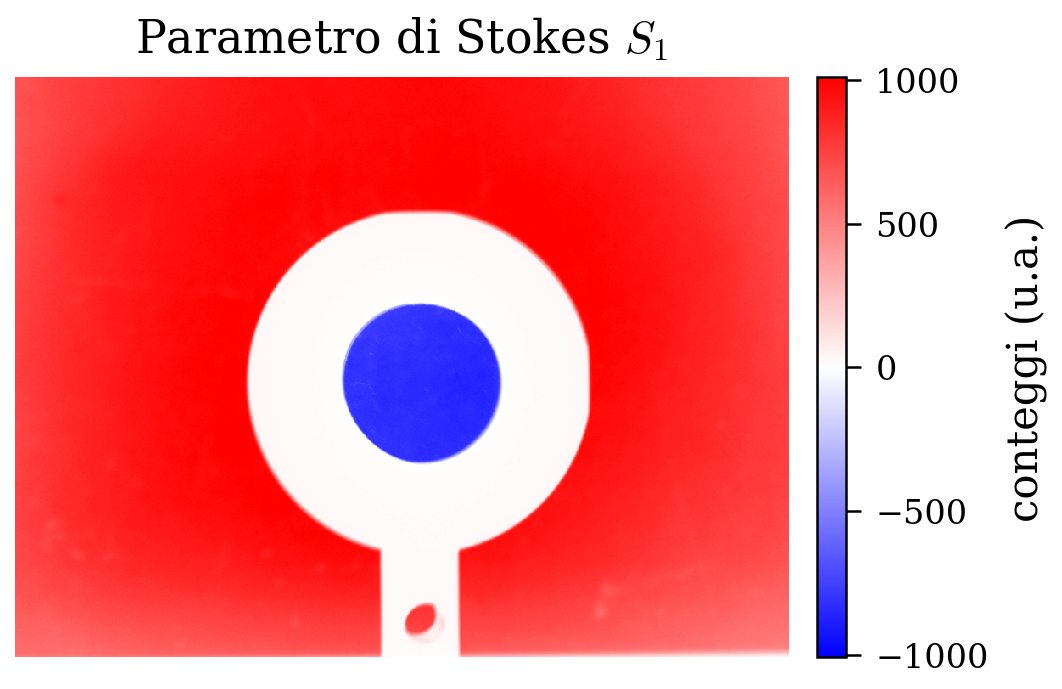

  saved: ../Images/generated\lambdamezzi_50deg\R_S2.pdf


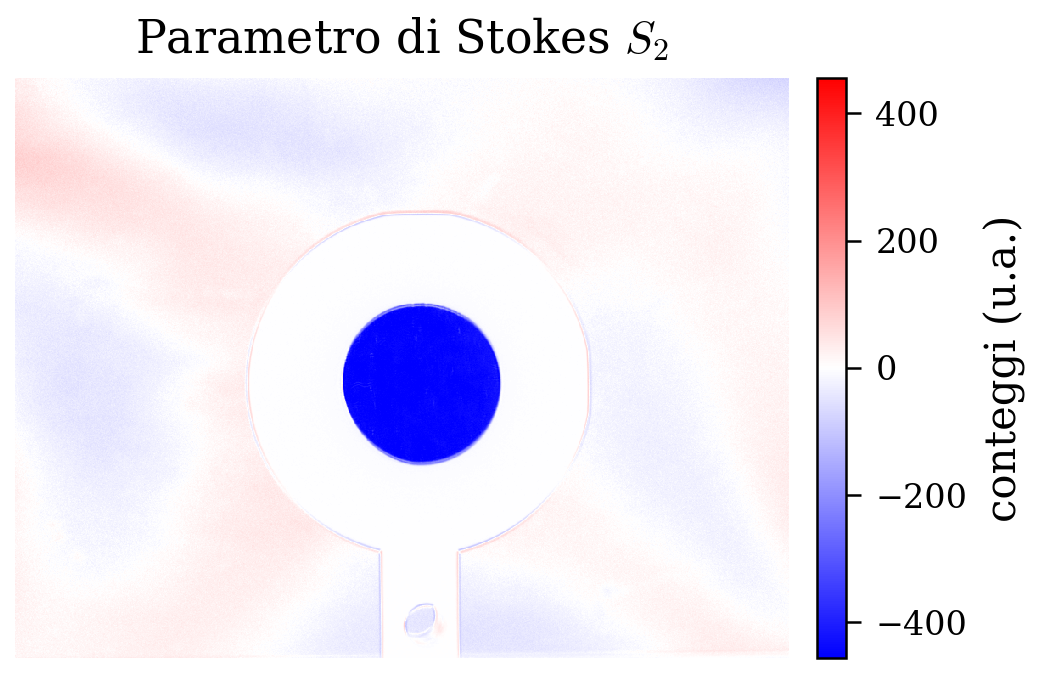

  saved: ../Images/generated\lambdamezzi_50deg\R_S3.pdf


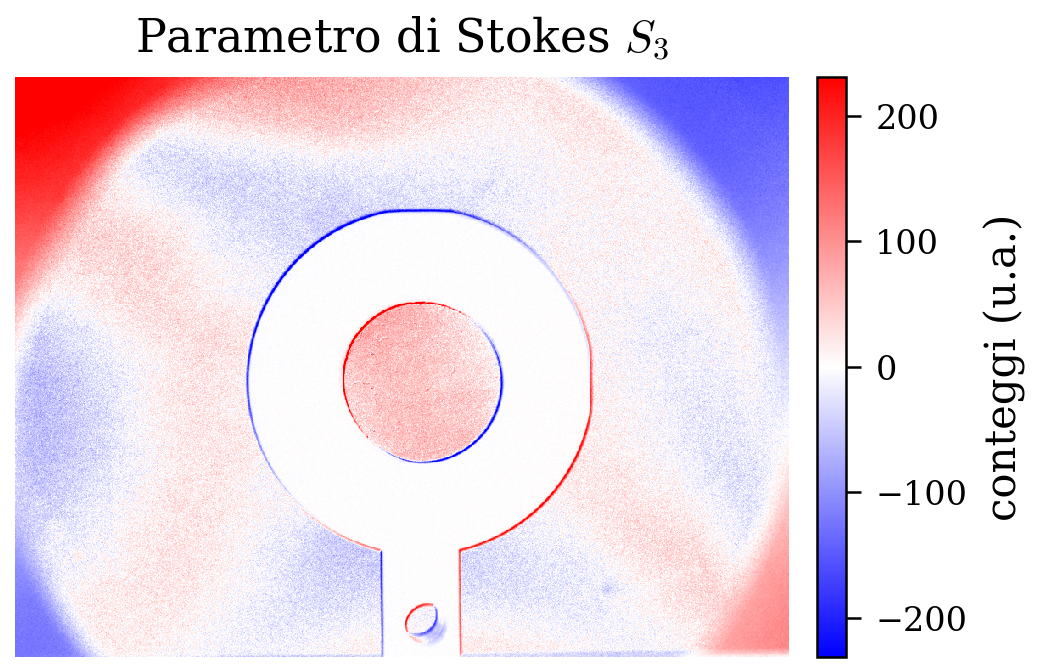

In [ ]:
if 'B' in active_analyses and stokes_data:
    out_dir = os.path.join(OUTPUT_DIR, DATASET)
    interactive_dir = os.path.join(out_dir, 'interactive')
    if SAVE_PLOTS:
        os.makedirs(out_dir, exist_ok=True)
        os.makedirs(interactive_dir, exist_ok=True)

    for ch in ACTIVE_CHANNELS:
        d = stokes_data[ch]
        for param in polplot.STOKES_PARAM_ORDER:
            data = d.get(param)
            if data is None:
                continue
            cfg = polplot.STOKES_PARAM_CONFIG[param]
            # S0 usa cmap nero→colore_canale (R/G/B); altri parametri il cmap da config.
            cmap = polplot.make_s0_cmap(d['channel_idx']) if cfg['cmap'] is None else cfg['cmap']
            fig = polplot.make_param_figure(
                data, title=cfg['titolo'], unit=cfg['unita'],
                cmap=cmap, vmin=cfg['vmin'], vmax=cfg['vmax'])
            pdf_path = os.path.join(out_dir, f"{ch}_{param}.pdf") if SAVE_PLOTS else None
            polplot.save_and_show(fig, pdf_path, show=(ch in DISPLAY_CHANNELS), fmt='pdf')
            plt.close(fig)
            if SAVE_PLOTS:
                html_path = os.path.join(interactive_dir, f"{ch}_{param}.html")
                polplot.save_param_html(
                    data, html_path, title=cfg['titolo'], unit=cfg['unita'],
                    cmap=cmap, vmin=cfg['vmin'], vmax=cfg['vmax'])


## C-aolp — UMAP colorato per AoLP

Embedding UMAP sparso a risoluzione nativa (subsample random ~30k pixel),
colorato per AoLP (cmap viridis, range autoscala 1–99 pct). Default per `zucchero`.


In [ ]:
if 'C-aolp' in active_analyses:
    # cache UMAP è per (DATASET, DS): se cambia, invalida e ricostruisci.
    _UMAP_CACHE_KEY_CURRENT = (DATASET, int(DOWNSAMPLE_FACTOR))
    _UMAP_CACHE_KEY_PREV = globals().get('_UMAP_CACHE_KEY')
    if _UMAP_CACHE_KEY_PREV != _UMAP_CACHE_KEY_CURRENT:
        if globals().get('UMAP_CACHE_BY_CHANNEL'):
            print(f"[cache] reset UMAP_CACHE_BY_CHANNEL: "
                  f"{_UMAP_CACHE_KEY_PREV} -> {_UMAP_CACHE_KEY_CURRENT}")
        UMAP_CACHE_BY_CHANNEL = {}
        _UMAP_CACHE_KEY = _UMAP_CACHE_KEY_CURRENT

    for ch in ACTIVE_CHANNELS:
        print(f"\n=== UMAP {DATASET} / {ch} (color_by=aolp) ===")
        sd = stokes_data.get(ch)
        if sd is None:
            print(f"  [{ch}] skip: mancano stokes_data (eseguire Load+Stokes prima)")
            continue
        result = polumap.compute_or_load_umap_cache(ch, sd, DATASET)
        if result is None:
            continue
        embedding, aolp, delta, valid_indices, S0_shape = result
        UMAP_CACHE_BY_CHANNEL[ch] = result
        spec = polumap.color_spec('aolp', aolp_deg=aolp, delta_deg=delta,
                                   valid_indices=valid_indices)
        out = polumap.export_umap_panels(
            spec, embedding, valid_indices, S0_shape,
            DATASET, ch, OUTPUT_DIR,
            save_plots=(SAVE_PLOTS and ch in DISPLAY_CHANNELS),
            bg_mask=sd['bg_mask'])
        print(f"  [{ch}/aolp] esportato: {out}/")


## C-delta — UMAP colorato per δ

Stesso fit di C-aolp (cache condivisa per canale), colorato per retardance
δ ∈ [0°, 360°) con cmap ciclica `twilight`. Bande di esclusione ±20° per
ignorare il wrap. Default per dataset λ-quarti, λ-mezzi, strati.


In [ ]:
if 'C-delta' in active_analyses:
    # cache UMAP è per (DATASET, DS): se cambia, invalida e ricostruisci.
    _UMAP_CACHE_KEY_CURRENT = (DATASET, int(DOWNSAMPLE_FACTOR))
    _UMAP_CACHE_KEY_PREV = globals().get('_UMAP_CACHE_KEY')
    if _UMAP_CACHE_KEY_PREV != _UMAP_CACHE_KEY_CURRENT:
        if globals().get('UMAP_CACHE_BY_CHANNEL'):
            print(f"[cache] reset UMAP_CACHE_BY_CHANNEL: "
                  f"{_UMAP_CACHE_KEY_PREV} -> {_UMAP_CACHE_KEY_CURRENT}")
        UMAP_CACHE_BY_CHANNEL = {}
        _UMAP_CACHE_KEY = _UMAP_CACHE_KEY_CURRENT

    for ch in ACTIVE_CHANNELS:
        print(f"\n=== UMAP {DATASET} / {ch} (color_by=delta) ===")
        # se già calcolato da C-aolp, riusa l'embedding; altrimenti calcola.
        result = UMAP_CACHE_BY_CHANNEL.get(ch)
        if result is None:
            sd = stokes_data.get(ch)
            if sd is None:
                print(f"  [{ch}] skip: mancano stokes_data")
                continue
            result = polumap.compute_or_load_umap_cache(ch, sd, DATASET)
            if result is None:
                continue
            UMAP_CACHE_BY_CHANNEL[ch] = result
        embedding, aolp, delta, valid_indices, S0_shape = result
        spec = polumap.color_spec('delta', aolp_deg=aolp, delta_deg=delta,
                                   valid_indices=valid_indices)
        sd_for_mask = stokes_data.get(ch)
        out = polumap.export_umap_panels(
            spec, embedding, valid_indices, S0_shape,
            DATASET, ch, OUTPUT_DIR,
            save_plots=(SAVE_PLOTS and ch in DISPLAY_CHANNELS),
            bg_mask=(sd_for_mask['bg_mask'] if sd_for_mask else None))
        print(f"  [{ch}/delta] esportato: {out}/")


## C-debug — Diagnostico campionamento UMAP

Mostra dove cadono i pixel random del subsample nello spazio immagine.
Gated da `C-aolp` o `C-delta` attive nel dispatcher.


In [ ]:
if ('C-aolp' in active_analyses or 'C-delta' in active_analyses) and stokes_data:
    # mostra dove cadono i pixel random del subsample (debug visivo).
    diag_chs = [ch for ch in ACTIVE_CHANNELS
                if ch in UMAP_CACHE_BY_CHANNEL and ch in DISPLAY_CHANNELS]
    if diag_chs:
        ncols = len(diag_chs)
        fig, axs = plt.subplots(1, ncols, figsize=(3.5 * ncols, 3.5))
        if ncols == 1:
            axs = [axs]
        for ax, ch in zip(axs, diag_chs):
            embedding, aolp, delta, valid_indices, S0_shape = UMAP_CACHE_BY_CHANNEL[ch]
            sample_mask = np.zeros(S0_shape, dtype=bool)
            flat = np.array(valid_indices, dtype=np.int64)
            ys, xs = np.unravel_index(flat, S0_shape)
            sample_mask[ys, xs] = True
            polumap.plot_sample_diagnostic(
                ax, stokes_data[ch]['S0'], sample_mask,
                bg_mask=stokes_data[ch]['bg_mask'],
                title=f'{DATASET} / {ch} — N={len(flat)}')
        plt.tight_layout()
        if SAVE_PLOTS:
            out = os.path.join(OUTPUT_DIR, DATASET, 'umap_sample_diagnostic.pdf')
            os.makedirs(os.path.dirname(out), exist_ok=True)
            fig.savefig(out, dpi=300, bbox_inches='tight')
            print(f'debug sample plot: {out}')
        plt.show()


## D-aolp — Cluster vincente AoLP via HDBSCAN su UMAP

HDBSCAN sull'embedding UMAP (richiede `UMAP_CACHE_BY_CHANNEL` da C-aolp/C-delta).
Score `size_frac × R × ang_dist_deg²`: penalizza cluster grossi vicini al
centroide globale (bg) e cluster piccoli rumorosi; premia cluster medio
con AoLP distinto dalla maggioranza. Popola `D_AOLP_RESULTS[ch]`.


In [ ]:
if 'D-aolp' in active_analyses and stokes_data:
    if not globals().get('UMAP_CACHE_BY_CHANNEL'):
        raise RuntimeError(
            "D-aolp richiede UMAP_CACHE_BY_CHANNEL popolato. "
            "Eseguire prima C-aolp (o C-delta).")

    MIN_CLUSTER_SIZE = 100   # parametro HDBSCAN, ~1% di N_sample tipico

    D_AOLP_RESULTS = {}
    for ch in ACTIVE_CHANNELS:
        sd = stokes_data.get(ch)
        if sd is None:
            continue
        entry = UMAP_CACHE_BY_CHANNEL.get(ch)
        if entry is None:
            print(f"  [D-aolp {ch}] skip: nessun embedding UMAP nel cache")
            continue
        embedding, _aolp_emb, _delta_emb, valid_indices, S0_shape = entry

        cluster_masks, info, win_idx, labels = polumap.cluster_umap_hdbscan_by_aolp(
            embedding, sd['AoLP'], valid_indices, sd['AoLP'].shape,
            min_cluster_size=MIN_CLUSTER_SIZE)
        if cluster_masks is None:
            print(f"  [D-aolp {ch}] skip: troppi pochi punti")
            continue

        print(f"\n=== D-aolp HDBSCAN {DATASET}/{ch} "
              f"(min_cluster_size={MIN_CLUSTER_SIZE}) ===")
        for i, c in enumerate(info):
            mark = '  <-- WINNER' if i == win_idx else ''
            noise = '  [noise]' if c['label'] == -1 else ''
            print(f"  L{c['label']:+d}: n={c['size']} ({c['size_frac']*100:.1f}%), "
                  f"mean={c['mean_deg']:+.1f}°, med={c['median_deg']:+.1f}°, "
                  f"std={c['std_deg']:.1f}°, R={c['R']:.3f}, "
                  f"d_ang={c['ang_dist_deg']:.1f}°, score={c['score']:.3f}{mark}{noise}")

        if win_idx < 0:
            print(f"  [D-aolp {ch}] nessun cluster valido")
            continue

        D_AOLP_RESULTS[ch] = dict(info[win_idx])
        polcluster.plot_cluster_winner_panels(
            mode='aolp', channel=ch, dataset=DATASET,
            stokes_data_ch=sd, cache_entry=entry,
            cluster_masks=cluster_masks, info=info,
            win_idx=win_idx, labels=labels,
            output_dir=OUTPUT_DIR,
            save_plots=SAVE_PLOTS, show=(ch in DISPLAY_CHANNELS))


## D-aolp-fit — Dispersione AoLP(λ) ∝ 1/λ²

Fit `ψ(λ) = k / λ²` (regola di Drude per attività ottica naturale) sulle
mediane AoLP del cluster vincente per canale RGB. Richiede `D_AOLP_RESULTS`
e `outputs/rgb_wavelengths.csv` (cella G0).


In [ ]:
if 'D-aolp-fit' in active_analyses and globals().get('D_AOLP_RESULTS'):
    # Estrai mediane AoLP del cluster vincente per canale + λ centroide.
    lams, vals, chs = [], [], []
    for ch in ('R', 'G', 'B'):
        info = D_AOLP_RESULTS.get(ch)
        if info is None or not np.isfinite(info.get('median_deg', np.nan)):
            print(f"  [D-aolp-fit {ch}] skip: nessun winner")
            continue
        lams.append(polcfg.get_channel_wavelength(WAVELENGTHS_CSV, CHANNELS_RGB[ch]))
        vals.append(float(info['median_deg']))
        chs.append(ch)

    print(f"\n=== D-aolp-fit {DATASET} ===")
    for ch, lam, val in zip(chs, lams, vals):
        print(f"  {ch}: lambda={lam:.0f} nm, AoLP_med={val:+.2f}deg")

    # Fit ψ(λ) = k / λ²  (Drude per attività ottica naturale).
    fit = poldisp.fit_inverse_lambda(lams, vals, power=2)
    if np.isfinite(fit['k']):
        print(f"  fit psi = k/lambda^2:  k = {fit['k']:.3e} +/- {fit['k_err']:.1e} deg·nm^2, "
              f"R^2 = {fit['r2']:.4f}")
    else:
        print("  WARN: meno di 2 canali validi, fit non eseguito")

    out_dir = os.path.join(OUTPUT_DIR, DATASET) if SAVE_PLOTS else None
    pdf = (os.path.join(out_dir, 'aolp_lambda_fit.pdf')
            if out_dir is not None else None)
    poldisp.plot_dispersion_fit(
        fit, channel_labels=chs,
        ylabel=r'AoLP mediano $\tilde\psi$ (°)',
        var_tex=r'\psi', out_pdf=pdf, show=True,
        legend_value_fmt='{:+.2f}', legend_value_unit='°',
        figsize=(4.0, 3.5))


## D-delta — Cluster vincente δ via HDBSCAN su UMAP

Mirror di D-aolp ma su retardance δ ∈ [0°, 360°). Median calcolata in frame
locale per gestire il wrap a 0°/360°. Escluso `strati_v2` (δ varia con
continuità lungo gli strati, non si rompe in cluster discreti).


In [ ]:
if 'D-delta' in active_analyses and stokes_data:
    if not globals().get('UMAP_CACHE_BY_CHANNEL'):
        raise RuntimeError(
            "D-delta richiede UMAP_CACHE_BY_CHANNEL popolato. "
            "Eseguire prima C-delta (o C-delta).")

    MIN_CLUSTER_SIZE = 100   # parametro HDBSCAN, ~1% di N_sample tipico

    D_DELTA_RESULTS = {}
    for ch in ACTIVE_CHANNELS:
        sd = stokes_data.get(ch)
        if sd is None:
            continue
        entry = UMAP_CACHE_BY_CHANNEL.get(ch)
        if entry is None:
            print(f"  [D-delta {ch}] skip: nessun embedding UMAP nel cache")
            continue
        embedding, _aolp_emb, _delta_emb, valid_indices, S0_shape = entry

        cluster_masks, info, win_idx, labels = polumap.cluster_umap_hdbscan_by_delta(
            embedding, sd['delta'], valid_indices, sd['delta'].shape,
            min_cluster_size=MIN_CLUSTER_SIZE)
        if cluster_masks is None:
            print(f"  [D-delta {ch}] skip: troppi pochi punti")
            continue

        print(f"\n=== D-delta HDBSCAN {DATASET}/{ch} "
              f"(min_cluster_size={MIN_CLUSTER_SIZE}) ===")
        for i, c in enumerate(info):
            mark = '  <-- WINNER' if i == win_idx else ''
            noise = '  [noise]' if c['label'] == -1 else ''
            print(f"  L{c['label']:+d}: n={c['size']} ({c['size_frac']*100:.1f}%), "
                  f"mean={c['mean_deg']:+.1f}°, med={c['median_deg']:+.1f}°, "
                  f"std={c['std_deg']:.1f}°, R={c['R']:.3f}, "
                  f"d_ang={c['ang_dist_deg']:.1f}°, score={c['score']:.3f}{mark}{noise}")

        if win_idx < 0:
            print(f"  [D-delta {ch}] nessun cluster valido")
            continue

        D_DELTA_RESULTS[ch] = dict(info[win_idx])
        polcluster.plot_cluster_winner_panels(
            mode='delta', channel=ch, dataset=DATASET,
            stokes_data_ch=sd, cache_entry=entry,
            cluster_masks=cluster_masks, info=info,
            win_idx=win_idx, labels=labels,
            output_dir=OUTPUT_DIR,
            save_plots=SAVE_PLOTS, show=(ch in DISPLAY_CHANNELS))


## D-delta-fit — Dispersione δ(λ) ∝ 1/λ

Fit `δ(λ) = k/λ` (quarzo zero-order: Δn ≈ costante → δ ∝ 1/λ). Aggiunge un
punto di ancoraggio di design se presente in `polcfg.WAVEPLATE_DESIGN_ANCHOR`
(180° @ 633 nm per λ/2, 90° @ 633 nm per λ/4).


In [ ]:
if 'D-delta-fit' in active_analyses and globals().get('D_DELTA_RESULTS'):
    # Estrai mediane delta del cluster vincente per canale + lambda centroide.
    # NB: il punto di design NON entra nel fit, ma e' mostrato nel plot.
    lams, vals, chs = [], [], []
    for ch in ('R', 'G', 'B'):
        info = D_DELTA_RESULTS.get(ch)
        if info is None:
            continue
        lams.append(polcfg.get_channel_wavelength(WAVELENGTHS_CSV, CHANNELS_RGB[ch]))
        vals.append(float(info['median_deg']))
        chs.append(ch)

    # Punto di design (180 @ 633 per lambda/2, 90 per lambda/4): mostrato come
    # riferimento nel plot ma ESCLUSO dal fit (valore nominale, non una misura).
    anchor_cfg = polcfg.WAVEPLATE_DESIGN_ANCHOR.get(DATASET)
    design_point = None
    if anchor_cfg is not None:
        design_point = {
            'lambda_nm': float(anchor_cfg['wavelength_nm']),
            'value': float(anchor_cfg['delta_deg']),
        }
        print(f"  punto di design (solo plot, non fittato): "
              f"lambda={design_point['lambda_nm']:.0f} nm, "
              f"delta={design_point['value']:.1f}deg")

    if len(lams) < 2:
        print("  [D-delta-fit] skip: meno di 2 punti misurati")
    else:
        # Fit delta(lambda) = k/lambda solo sui punti misurati R/G/B (design escluso).
        fit = poldisp.fit_inverse_lambda(lams, vals, power=1)
        print(f"  fit delta(lambda) = k/lambda (solo R/G/B):  "
              f"k = {fit['k']:.3e} +/- {fit['k_err']:.1e} deg*nm,  R^2 = {fit['r2']:.4f}")

        out_dir = os.path.join(OUTPUT_DIR, DATASET) if SAVE_PLOTS else None
        pdf = (os.path.join(out_dir, 'delta_lambda_fit.pdf')
                if out_dir is not None else None)
        poldisp.plot_dispersion_fit(
            fit, channel_labels=chs, design_point=design_point,
            ylabel=r'Ritardo di fase $\delta$ (deg)',
            var_tex=r'\delta', out_pdf=pdf, show=True,
            legend_value_fmt='{:.1f}', legend_value_unit='deg',
            legend_loc='lower left', figsize=(3.5, 3.5))


## MO -- Fit multi-ordine dello spessore (lamina ad alto ordine)

In [ ]:
if 'MO' in active_analyses and globals().get('D_DELTA_RESULTS'):
    # Fit multi-ordine: delta_tot(lambda) = 360*dn(lambda)*d/lambda supera molti
    # giri e la misura ne da' il residuo mod 360. Il modello zero-order k/lambda
    # non descrive la dispersione del valore avvolto; qui si stima lo spessore d.
    import matplotlib.pyplot as plt
    import numpy as np

    lams, vals, chs = [], [], []
    for ch in ('R', 'G', 'B'):
        info = D_DELTA_RESULTS.get(ch)
        if info is None:
            continue
        lams.append(polcfg.get_channel_wavelength(WAVELENGTHS_CSV, CHANNELS_RGB[ch]))
        vals.append(float(info['median_deg']))
        chs.append(ch)

    if len(lams) < 2:
        print("  [MO] skip: meno di 2 punti misurati")
    else:
        mo = poldisp.fit_multiorder_waveplate(lams, vals, pol.quartz_birefringence)
        zo = poldisp.fit_inverse_lambda(lams, vals, power=1)
        print()
        print(f"=== MO multi-ordine {DATASET} ===")
        print(f"  d = {mo['d_nm']/1000:.2f} um, ordine(633) = {mo['order']:.2f}, "
              f"RMS = {mo['rms_deg']:.2f} deg")
        print(f"  pred avvolto = {np.round(mo['pred_deg'], 1).tolist()} "
              f"vs misurato {[round(v, 1) for v in vals]}")
        print(f"  confronto zero-order k/lambda: R^2 = {zo['r2']:.4f}")

        anchor_cfg = polcfg.WAVEPLATE_DESIGN_ANCHOR.get(DATASET)
        fig, ax = plt.subplots(figsize=(4.2, 3.5))
        # curva modello multi-ordine avvolta (NaN ai wrap per spezzare la linea)
        lam_c = np.linspace(420.0, 680.0, 3000)
        dn_c = np.array([pol.quartz_birefringence(float(l)) for l in lam_c])
        model = (360.0 * dn_c * mo['d_nm'] / lam_c) % 360.0
        model_plot = model.copy()
        jump = np.abs(np.diff(model)) > 180.0
        model_plot[:-1][jump] = np.nan
        ax.plot(lam_c, model_plot, 'k--', lw=0.8,
                label=fr"multi-ordine $d={mo['d_nm']/1000:.2f}$ um")
        colors = {'R': 'tab:red', 'G': 'tab:green', 'B': 'tab:blue'}
        for lam, val, ch in zip(lams, vals, chs):
            ax.scatter(lam, val, s=46, color=colors.get(ch, 'gray'), zorder=3,
                       edgecolors='none', label=f"{ch} ({lam:.0f} nm, {val:.1f} deg)")
        if anchor_cfg is not None:
            ax.scatter([float(anchor_cfg['wavelength_nm'])],
                       [float(anchor_cfg['delta_deg'])], s=46, marker='D',
                       color='black', zorder=3,
                       label=f"design ({anchor_cfg['wavelength_nm']:.0f} nm, "
                             f"{anchor_cfg['delta_deg']:.0f} deg, non fittato)")
        ax.set_xlabel(r"Lunghezza d'onda $\lambda$ (nm)")
        ax.set_ylabel(r'Ritardo di fase $\delta$ (deg)')
        ax.set_xlim(400, 700); ax.set_ylim(0, 360)
        ax.set_yticks(np.arange(0, 361, 60))
        ax.set_title(fr"Fit multi-ordine: $d={mo['d_nm']/1000:.2f}$ um, "
                     fr"ordine ~ {mo['order']:.1f}, RMS = {mo['rms_deg']:.1f} deg",
                     fontsize=9, pad=4)
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.legend(loc='best', fontsize=7, framealpha=0.85)
        fig.tight_layout()
        out_dir = os.path.join(OUTPUT_DIR, DATASET) if SAVE_PLOTS else None
        pdf = os.path.join(out_dir, 'delta_multiorder_fit.pdf') if out_dir else None
        polplot.save_and_show(fig, pdf, show=True, fmt='pdf')
        plt.close(fig)


## F — Slice diagonale δ multistrato

Tre pannelli per `strati_v2`: mappa δ con banda della slice evidenziata,
profilo 1D con plateau etichettati 1L→5→1R, fit lineare attraverso l'origine
con unwrap separato L/R. Popola `STRATI_SLICE_RESULTS[ch]` per le celle E e H.


In [ ]:
if 'F' in active_analyses:
    from matplotlib.lines import Line2D as _Line2D_F
    try:
        import plotly.graph_objects as _go_F
        _PLOTLY_OK_F = True
    except ImportError:
        _PLOTLY_OK_F = False

    SLICE_ANCHOR_F = (767, 422)
    SLICE_ANGLE_F = 141.0
    SLICE_HALF_WIDTH_NATIVE_F = 200.0
    SLICE_STEP_NATIVE_F = 5.0
    AUTO_CROP_MARGIN_F = 15.0
    AUTO_CROP_IGNORE_NATIVE_F = 1500.0
    PLATEAU_SIGMA_F = 1.5
    PLATEAU_GRAD_F = 1.0
    PLATEAU_MIN_LEN_NATIVE_F = 20.0
    PLATEAU_LABELS_F = ['1L', '2L', '3L', '4L', '5', '4R', '3R', '2R', '1R']

    from polarimetro import slice_fit as polslice

    _out_F = os.path.join(OUTPUT_DIR, DATASET)
    _out_html_F = os.path.join(_out_F, 'interactive')
    os.makedirs(_out_F, exist_ok=True)
    os.makedirs(_out_html_F, exist_ok=True)

    STRATI_SLICE_RESULTS = {}
    for _ch in ACTIVE_CHANNELS:
        _sd = stokes_data.get(_ch)
        if _sd is None:
            print(f"  [F {_ch}] skip: mancano stokes_data"); continue
        print(f"\n=== F slice {DATASET} / {_ch} ===")
        _delta = _sd['delta']
        _ch_idx = _sd['channel_idx']
        _wavelength = polcfg.get_channel_wavelength(WAVELENGTHS_CSV, _ch_idx)

        _t_vals, _X, _Y, _center = polslice.build_slice_grid(
            _delta.shape, SLICE_ANCHOR_F, SLICE_ANGLE_F,
            DOWNSAMPLE_FACTOR, SLICE_HALF_WIDTH_NATIVE_F, SLICE_STEP_NATIVE_F)
        _profile, _circ_std = polslice.sample_thick_delta(_delta, _X, _Y)
        _crop_idx = polslice.find_auto_crop(_profile, _t_vals, DOWNSAMPLE_FACTOR,
                                 AUTO_CROP_MARGIN_F, AUTO_CROP_IGNORE_NATIVE_F)
        _plateaus = polslice.detect_plateaus(
            _profile, _t_vals, DOWNSAMPLE_FACTOR, _crop_idx,
            PLATEAU_SIGMA_F, PLATEAU_GRAD_F, PLATEAU_MIN_LEN_NATIVE_F,
            PLATEAU_LABELS_F)
        _fit = polslice.fit_layers(_plateaus) if _plateaus else None
        print(f"  plateau rilevati: {len(_plateaus)}, fit: {'OK' if _fit else 'none'}")
        if _fit is not None:
            STRATI_SLICE_RESULTS[_ch] = {
                'x_layer': np.array(_fit['x'], dtype=float),
                'y_delta': np.array(_fit['y'], dtype=float),
                'labels': list(_fit.get('labels', [])),
                'slope': float(_fit['slope']),
                'n_unwrapped': int(_fit.get('n_unwrapped', 0)),
                'r2': float(_fit.get('r2', np.nan)),
                'rms': float(_fit.get('rms', np.nan)),
                'wavelength': float(_wavelength),
            }

        if _fit is not None:
            fig, axes = plt.subplots(
                1, 3, figsize=(11.0, 3.6),
                gridspec_kw={'width_ratios': [1.0, 1.4, 0.7]})
        else:
            fig, axes = plt.subplots(
                1, 2, figsize=(8.5, 3.6),
                gridspec_kw={'width_ratios': [1.0, 1.3]})

        ax_map = axes[0]
        im = ax_map.imshow(_delta, cmap='twilight', vmin=0, vmax=360, origin='upper')
        cb = fig.colorbar(im, ax=ax_map, fraction=0.046, pad=0.03)
        cb.set_label(r'$\delta$ (°)')
        mid_col = _X.shape[1] // 2
        s_c, e_c = _crop_idx
        sl = slice(s_c, e_c + 1)
        ax_map.plot(_X[:, mid_col], _Y[:, mid_col], '-', color='gray', lw=0.5, alpha=0.5)
        ax_map.plot(_X[:, 0], _Y[:, 0], 'w-', lw=0.4, alpha=0.4)
        ax_map.plot(_X[:, -1], _Y[:, -1], 'w-', lw=0.4, alpha=0.4)
        ax_map.plot(_X[sl, mid_col], _Y[sl, mid_col], 'r-', lw=1.0)
        ax_map.plot(_X[sl, 0], _Y[sl, 0], 'y-', lw=0.6, alpha=0.9)
        ax_map.plot(_X[sl, -1], _Y[sl, -1], 'y-', lw=0.6, alpha=0.9)
        ax_map.plot(_center[0], _center[1], 'r+', mew=1.5, ms=8)
        ax_map.set_xlim(0, _delta.shape[1] - 1)
        ax_map.set_ylim(_delta.shape[0] - 1, 0)
        ax_map.set_xticks([]); ax_map.set_yticks([])
        ax_map.set_title(fr'Mappa di $\delta$ - canale {_ch} '
                         fr'($\lambda={_wavelength:.0f}$ nm)', pad=6)

        ax_prof = axes[1]
        arc_native = _t_vals * DOWNSAMPLE_FACTOR
        ax_prof.plot(arc_native[sl], _profile[sl], 'k-', lw=1.1,
                     label=r'$\delta$ medio (banda)')
        ax_prof.fill_between(arc_native[sl],
                             _profile[sl] - _circ_std[sl],
                             _profile[sl] + _circ_std[sl],
                             color='gray', alpha=0.25,
                             label=r'$\pm \sigma$ circolare')
        ax_prof.axhline(0, color='lightgray', lw=0.4)
        ax_prof.axhline(360, color='lightgray', lw=0.4)
        for p in _plateaus:
            ax_prof.plot([p['arc_start'], p['arc_end']],
                         [p['delta_med'], p['delta_med']],
                         color='tab:red', lw=2.0, solid_capstyle='butt', zorder=5)
            ax_prof.axvspan(p['arc_start'], p['arc_end'],
                            color='tab:red', alpha=0.05, zorder=0)
            ax_prof.annotate(
                f"{p['label']}\n{p['delta_med']:.1f}°",
                xy=(p['arc_mid'], p['delta_med']),
                xytext=(0, 10), textcoords='offset points',
                ha='center', va='bottom', fontsize=7, color='tab:red',
                bbox=dict(boxstyle='round,pad=0.2', fc='white',
                          ec='tab:red', lw=0.4, alpha=0.85),
                zorder=6)
        if _plateaus:
            ax_prof.plot([], [], color='tab:red', lw=2.0, label='plateau (mediana)')
        ax_prof.set_xlabel('ascissa curvilinea lungo la slice (px nativi)')
        ax_prof.set_ylabel(r'$\delta$ (°)')
        ax_prof.set_ylim(-10, 370)
        ax_prof.set_yticks(np.arange(0, 361, 60))
        ax_prof.grid(alpha=0.3)
        ax_prof.legend(loc='lower right', fontsize=7, framealpha=0.9)
        ax_prof.set_title(
            fr'Profilo lungo slice a {SLICE_ANGLE_F:.0f}° '
            f'(ancora ({SLICE_ANCHOR_F[0]}, {SLICE_ANCHOR_F[1]}))', pad=6)

        if _fit is not None:
            ax_fit = axes[2]
            x_fit = _fit['x']; y_fit = _fit['y']; slope = _fit['slope']
            for xi, yi, lbl in zip(x_fit, y_fit, _fit['labels']):
                if lbl.endswith('L'):
                    marker, color = 'o', 'tab:blue'
                elif lbl.endswith('R'):
                    marker, color = 's', 'tab:orange'
                else:
                    marker, color = 'D', 'tab:green'
                ax_fit.plot(xi, yi, marker=marker, color=color, ms=6,
                            markeredgecolor='k', markeredgewidth=0.5,
                            linestyle='none', zorder=3)
                ax_fit.annotate(lbl, (xi, yi), xytext=(4, 3),
                                textcoords='offset points', fontsize=6)
            x_max = float(x_fit.max())
            xs = np.array([0.0, x_max + 0.3])
            ax_fit.plot(xs, slope * xs, 'k--', lw=1.0,
                        label=fr'$\delta = {slope:.2f}\,n$')
            n_unw = int(_fit.get('n_unwrapped', 0))
            if n_unw:
                ax_fit.plot(x_fit, _fit['y_raw'], 'x', color='gray',
                            ms=5, alpha=0.5, zorder=2)
            ax_fit.set_xlim(0, x_max + 0.5)
            ymax = max(float(y_fit.max()) * 1.05,
                       slope * (x_max + 0.3) * 1.05, 360.0)
            ax_fit.set_ylim(0, ymax)
            ax_fit.set_xlabel(r'numero di strati $n$')
            ax_fit.set_ylabel(r'$\delta$ unwrap (°)' if n_unw else r'$\delta$ (°)')
            ax_fit.grid(alpha=0.3)
            unw_note = f" (+{n_unw} unwrap)" if n_unw else ""
            ax_fit.set_title(
                fr'Fit $\delta = m\,n${unw_note}' '\n'
                fr'$m={slope:.2f}$°/strato, $R^2={_fit["r2"]:.3f}$',
                pad=6)
            handles = [
                _Line2D_F([], [], marker='o', color='tab:blue', linestyle='none',
                          markeredgecolor='k', markeredgewidth=0.5, label='lato sinistro (L)'),
                _Line2D_F([], [], marker='s', color='tab:orange', linestyle='none',
                          markeredgecolor='k', markeredgewidth=0.5, label='lato destro (R)'),
                _Line2D_F([], [], marker='D', color='tab:green', linestyle='none',
                          markeredgecolor='k', markeredgewidth=0.5, label='centro'),
                _Line2D_F([], [], color='k', linestyle='--', label='fit'),
            ]
            ax_fit.legend(handles=handles, loc='lower right', fontsize=6, framealpha=0.9)

        fig.suptitle(fr'Slice diagonale - {DATASET}, canale {_ch}', fontsize=11, y=1.02)
        fig.tight_layout()
        _pdf_path = os.path.join(_out_F, f"{_ch}_slice.pdf")
        polplot.save_and_show(fig, _pdf_path, show=(SAVE_PLOTS and _ch in DISPLAY_CHANNELS))
        plt.close(fig)

        if _PLOTLY_OK_F:
            arc_native_html = _t_vals * DOWNSAMPLE_FACTOR
            figh = _go_F.Figure()
            figh.add_trace(_go_F.Scatter(
                x=arc_native_html[sl], y=_profile[sl] + _circ_std[sl],
                mode='lines', line=dict(width=0, color='gray'),
                showlegend=False, hoverinfo='skip'))
            figh.add_trace(_go_F.Scatter(
                x=arc_native_html[sl], y=_profile[sl] - _circ_std[sl],
                mode='lines', line=dict(width=0, color='gray'),
                fill='tonexty', fillcolor='rgba(150,150,150,0.25)',
                name='± σ circolare', hoverinfo='skip'))
            figh.add_trace(_go_F.Scatter(
                x=arc_native_html[sl], y=_profile[sl],
                mode='lines', line=dict(color='black', width=1.5),
                name='δ medio (banda)',
                hovertemplate='ascissa: %{x:.0f} px<br>δ: %{y:.2f}°<extra></extra>'))
            for p in _plateaus:
                figh.add_trace(_go_F.Scatter(
                    x=[p['arc_start'], p['arc_end']],
                    y=[p['delta_med'], p['delta_med']],
                    mode='lines', line=dict(color='red', width=3),
                    name=f"{p['label']}: {p['delta_med']:.1f}°",
                    hovertemplate=(f"<b>{p['label']}</b><br>"
                                   f"δ = {p['delta_med']:.2f}°<br>"
                                   f"σ = {p['delta_std']:.2f}°<extra></extra>"),
                    showlegend=False))
            figh.update_layout(
                title=(f"Slice diagonale - {DATASET}, canale {_ch} "
                       f"(λ = {_wavelength:.0f} nm)"),
                xaxis=dict(title='ascissa curvilinea (px nativi)'),
                yaxis=dict(title='δ (°)', range=[-10, 370],
                           tickvals=list(range(0, 361, 60))),
                width=1000, height=520,
                margin=dict(l=70, r=30, t=70, b=60),
                template='simple_white', hovermode='x unified')
            _html_path = os.path.join(_out_html_F, f"{_ch}_slice.html")
            figh.write_html(_html_path, include_plotlyjs='cdn', full_html=True)
            print(f"  HTML salvato: {_html_path}")

## E — Istogramma δ + plateau strati

Istogramma δ pubblicabile con barre colorate `twilight` e plateau della
slice F come vline etichettate. Richiede `STRATI_SLICE_RESULTS` dalla cella F.


In [ ]:
if 'E' in active_analyses:
    if not globals().get('STRATI_SLICE_RESULTS'):
        raise RuntimeError(
            "E richiede STRATI_SLICE_RESULTS popolato dalla cella F. "
            "Eseguire prima F.")

    out_E = os.path.join(OUTPUT_DIR, DATASET)
    out_html_E = os.path.join(out_E, 'interactive')
    os.makedirs(out_E, exist_ok=True)
    os.makedirs(out_html_E, exist_ok=True)

    for ch in ACTIVE_CHANNELS:
        sd = stokes_data.get(ch)
        if sd is None:
            print(f"  [E {ch}] skip: mancano stokes_data"); continue
        sl = STRATI_SLICE_RESULTS.get(ch)
        if sl is None:
            raise RuntimeError(
                f"STRATI_SLICE_RESULTS['{ch}'] assente — re-eseguire F.")

        # δ del sample (esclude bg + NaN). I plateau della slice diventano vline.
        delta = sd['delta']
        delta_vals = delta[np.isfinite(delta) & (~sd['bg_mask'])]
        layer_delta_wrap = sl['y_delta'] % 360.0
        labels = list(sl.get('labels', []))
        if not labels or len(labels) != len(sl['x_layer']):
            raise RuntimeError(
                f"STRATI_SLICE_RESULTS['{ch}']['labels'] disallineato — re-eseguire F.")
        wavelength = sl['wavelength']
        title = (rf'Istogramma $\delta$ — {DATASET}/{ch} '
                  rf'(λ={wavelength:.0f} nm)')

        pdf_path = os.path.join(out_E, f'{ch}_hist_delta.pdf')
        polplot.plot_delta_strati_histogram(
            delta_vals, layer_delta_wrap, labels,
            title=title, out_pdf=pdf_path,
            show=(SAVE_PLOTS and ch in DISPLAY_CHANNELS))

        html_path = os.path.join(out_html_E, f'{ch}_hist_delta.html')
        polplot.save_delta_strati_histogram_html(
            delta_vals, layer_delta_wrap, sl['y_delta'], labels,
            html_path,
            title=f'{DATASET}/{ch}: hist δ + slice plateaus (λ={wavelength:.0f} nm)')

        print(f"  [E {ch}] hist + {len(labels)} vline da slice (lambda={wavelength:.0f} nm)")


## H — Fit retardance vs n strati + dispersione 1/λ

Punti δ per strato (3 canali RGB) + fit lineare `δ = m·n` attraverso l'origine
+ fit dispersivo `δ(λ) = k/λ` sulle slope per canale. Solo `strati_v2`.
Richiede `STRATI_SLICE_RESULTS` dalla cella F.


In [ ]:
if 'H' in active_analyses:
    try:
        import plotly.graph_objects as go
        PLOTLY_OK_H = True
    except ImportError:
        PLOTLY_OK_H = False

    if not globals().get('STRATI_SLICE_RESULTS'):
        raise RuntimeError(
            "H richiede STRATI_SLICE_RESULTS popolato dalla cella F. "
            "Eseguire prima F.")

    # Raccoglie δ_unwrap[strato] per ogni canale (popolato da cella F).
    n_strati = None
    delta_meas = {}
    for ch in ('R', 'G', 'B'):
        r = STRATI_SLICE_RESULTS.get(ch)
        if r is None:
            raise RuntimeError(
                f"STRATI_SLICE_RESULTS['{ch}'] assente — re-eseguire F.")
        delta_meas[ch] = r['y_delta']
        if n_strati is None:
            n_strati = r['x_layer'].astype(int)
    print(f"  H usa fit slice (F): {len(delta_meas)} canali, {len(n_strati)} layer")

    lambdas = np.array([polcfg.get_channel_wavelength(WAVELENGTHS_CSV, CHANNELS_RGB[ch])
                         for ch in ('R', 'G', 'B')])
    print(f"  lambda RGB = {lambdas[0]:.0f}, {lambdas[1]:.0f}, {lambdas[2]:.0f} nm")

    out_H = os.path.join(OUTPUT_DIR, 'strati_fit')
    os.makedirs(out_H, exist_ok=True)
    colors_H = {'R': 'tab:red', 'G': 'tab:green', 'B': 'tab:blue'}

    # --- Fit lineare δ = m·n through origin per canale + scatter ---
    slopes = []
    fig, ax = plt.subplots(figsize=(3.35, 3.35))
    for ch in ('R', 'G', 'B'):
        y = delta_meas[ch]
        # m = sum(x·y) / sum(x²) (least squares forzato a 0).
        m = float((n_strati * y).sum() / (n_strati ** 2).sum())
        slopes.append(m)
        ax.scatter(n_strati, y, color=colors_H[ch], s=15, zorder=3, alpha=0.8)
        x_line = np.linspace(0, max(5.5, float(n_strati.max()) + 0.5), 100)
        ax.plot(x_line, m * x_line, color=colors_H[ch], linestyle='--',
                linewidth=1.2, zorder=2,
                label=rf'{ch}: $\delta_{ch} \approx {m:.1f}^\circ/n$')
    ax.set_xlabel(r'Numero di strati $n$')
    ax.set_ylabel(r'Ritardo di fase srotolato $\delta_{unwrap}$ (°)')
    ax.set_xlim(0, max(5.5, float(n_strati.max()) + 0.5))
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='upper left')
    polplot.save_and_show(fig, os.path.join(out_H, 'fit_strati_linear.pdf'),
                          show=SAVE_PLOTS)
    plt.close(fig)

    # --- Fit dispersione δ(λ) = k/λ sulle slope per-canale ---
    slopes_arr = np.array(slopes)
    fit = poldisp.fit_inverse_lambda(lambdas, slopes_arr, power=1)
    print(f"  fit dispersione: k = {fit['k']:.3e} +/- {fit['k_err']:.1e} deg·nm/strato, "
          f"R^2 = {fit['r2']:.4f}")

    pdf_lam = os.path.join(out_H, 'fit_lambda_inverse.pdf')
    poldisp.plot_dispersion_fit(
        fit, channel_labels=['R', 'G', 'B'],
        ylabel=r'Ritardo specifico $\delta$ (°/strato)',
        var_tex=r'\delta', out_pdf=pdf_lam, show=SAVE_PLOTS,
        legend_value_fmt='{:.1f}', legend_value_unit='°/strato',
        legend_loc='upper right', figsize=(3.35, 3.35),
        y_pad_frac=1.4)

    # --- HTML interattivi ---
    if PLOTLY_OK_H:
        figh = go.Figure()
        for ch, color_rgb in [('R', 'rgb(214,39,40)'), ('G', 'rgb(44,160,44)'),
                                ('B', 'rgb(31,119,180)')]:
            y = delta_meas[ch]
            m = slopes[{'R': 0, 'G': 1, 'B': 2}[ch]]
            figh.add_trace(go.Scatter(
                x=n_strati, y=y, mode='markers',
                marker=dict(color=color_rgb, size=8),
                name=f"{ch} (slice fit)",
                hovertemplate=f'n=%{{x}}<br>δ=%{{y:.1f}}°<extra>{ch}</extra>'))
            x_line = np.linspace(0, max(5.5, float(n_strati.max()) + 0.5), 50)
            figh.add_trace(go.Scatter(
                x=x_line, y=m * x_line, mode='lines',
                line=dict(color=color_rgb, dash='dash', width=1.5),
                name=f"{ch}: δ≈{m:.1f}°/n"))
        figh.update_layout(
            title=f"Retardance vs numero di strati - {DATASET}",
            xaxis=dict(title='numero di strati n'),
            yaxis=dict(title='δ unwrap (°)'),
            template='simple_white', width=700, height=500,
            margin=dict(l=70, r=30, t=70, b=60))
        figh.write_html(os.path.join(out_H, 'fit_strati_linear.html'),
                         include_plotlyjs='cdn', full_html=True)

        figh2 = go.Figure()
        for i, (ch, color_rgb) in enumerate([('R', 'rgb(214,39,40)'),
                                              ('G', 'rgb(44,160,44)'),
                                              ('B', 'rgb(31,119,180)')]):
            figh2.add_trace(go.Scatter(
                x=[lambdas[i]], y=[slopes[i]], mode='markers',
                marker=dict(color=color_rgb, size=12), name=ch,
                hovertemplate=(f'λ=%{{x:.0f}} nm<br>δ=%{{y:.1f}}°/strato'
                                f'<extra>{ch}</extra>')))
        x_lam = np.linspace(150, 1100, 500)
        figh2.add_trace(go.Scatter(
            x=x_lam, y=fit['k'] / x_lam, mode='lines',
            line=dict(color='black', dash='dash'),
            name=f"fit k/λ, k={fit['k']:.2e}"))
        figh2.update_layout(
            title=f"Dispersione 1/λ - {DATASET}",
            xaxis=dict(title='λ (nm)', range=[0, 1100]),
            yaxis=dict(title='δ (°/strato)'),
            template='simple_white', width=700, height=500,
            margin=dict(l=70, r=30, t=70, b=60))
        figh2.write_html(os.path.join(out_H, 'fit_lambda_inverse.html'),
                         include_plotlyjs='cdn', full_html=True)
        print(f"  HTML interattivi salvati in {out_H}/")


## I — Fotoelasticità: allineamento + warp barraon vs barraoff

Solo `barraon_v2`. Carica la cache `barraoff_v2`, esegue:
1. Allineamento globale via phase-correlation FFT (ROI sul supporto destro).
2. Tracking centerline pixel-per-pixel + polyfit grado 2.
3. Warp di `barraon` su `barraoff` (Δy colonna-per-colonna).
4. ΔS3 = S3_warped(on) − S3(off) per canale → differenza qualitativa di
   ellitticità indotta dal carico.


In [ ]:
if 'I' in active_analyses and stokes_data:
    if DATASET != 'barraon_v2':
        raise RuntimeError("I richiede DATASET='barraon_v2'")

    from matplotlib.patches import Rectangle

    # ---------------------- parametri sezione I ----------------------
    # ROI per phase correlation: solo supporto destro (la parte flessa
    # non deve dominare il fit traslazionale).
    ALIGN_ROI_FRAC = (0.6, 0.95, 0.8, 0.975)   # (y0, y1, x0, x1) come frazioni
    ALIGN_FALLBACK_FULL = True                  # se err ROI > 0.5, retry su immagine intera
    # Tracking centerline barra (range x relativo + smoothing colonne + prominenza picchi).
    BARRA_X_FRAC = (0.17, 0.80)
    BARRA_EDGE_PROM_FRAC = 0.10
    BARRA_X_SMOOTH_HALF = 3
    BARRA_FIT_DEGREE = 2                        # parabola: cantilever bending atteso

    BARRA_FIELDS_2D = ('S0', 'S1', 'S2', 'S3', 'DoLP', 'AoLP', 'delta', 'theta',
                       'wav_intensity')
    BARRA_MASK_FIELDS = ('bg_mask', 'poincare_bg_mask', 'sat_mask')

    # ---------------------- carica cache barraoff ----------------------
    other_ds = 'barraoff_v2'
    other_cache = f'./outputs/stokes_{other_ds}_DS{DOWNSAMPLE_FACTOR}.npz'
    other_data = polpipe.load_cache_npz(
        other_cache, other_ds, DOWNSAMPLE_FACTOR, True,
        list(CHANNELS_RGB.keys()), CHANNELS_RGB)
    if other_data is None:
        raise RuntimeError(
            f"Cache {other_cache} mancante. Esegui prima con DATASET='{other_ds}'.")

    # ---------------------- S0 unificato RGB ----------------------
    S0_on_uni = np.mean(np.stack([stokes_data[ch]['S0'].astype(np.float32)
                                    for ch in CHANNELS_RGB], axis=0), axis=0)
    S0_off_uni_raw = np.mean(np.stack([other_data[ch]['S0'].astype(np.float32)
                                         for ch in CHANNELS_RGB], axis=0), axis=0)
    H_I, W_I = S0_on_uni.shape
    print(f"  [I] image DS shape (H, W) = ({H_I}, {W_I})")

    # Conversione ROI frazionaria → pixel.
    y0f, y1f, x0f, x1f = ALIGN_ROI_FRAC
    y0 = max(0, min(int(round(y0f * H_I)), H_I - 2))
    y1 = max(y0 + 1, min(int(round(y1f * H_I)), H_I))
    x0 = max(0, min(int(round(x0f * W_I)), W_I - 2))
    x1 = max(x0 + 1, min(int(round(x1f * W_I)), W_I))
    print(f"  [I] ROI DS coords: y[{y0}:{y1}] x[{x0}:{x1}]  size {y1-y0}x{x1-x0}")

    # ---------------------- phase correlation sul supporto destro ----------------------
    S0_on_clean = np.nan_to_num(S0_on_uni, nan=0.0, posinf=0.0, neginf=0.0)
    S0_off_clean = np.nan_to_num(S0_off_uni_raw, nan=0.0, posinf=0.0, neginf=0.0)
    dy, dx, err = polphoto.phase_correlation(
        S0_on_clean[y0:y1, x0:x1], S0_off_clean[y0:y1, x0:x1])
    print(f"  [I] shift ROI unified: dy={dy:+.2f}, dx={dx:+.2f}  err={err:.3e}")
    if ALIGN_FALLBACK_FULL and err > 0.5:
        dy, dx, err = polphoto.phase_correlation(S0_on_clean, S0_off_clean)
        print(f"  [I] shift FULL unified: dy={dy:+.2f}, dx={dx:+.2f}  err={err:.3e}")
    shift_yx = np.array([dy, dx])

    # Applica shift a TUTTI i campi 2D + maschere di barraoff in-place.
    polphoto.shift_dict_inplace(other_data, shift_yx,
                                  BARRA_FIELDS_2D, BARRA_MASK_FIELDS)
    S0_off_uni = np.mean(np.stack([other_data[ch]['S0'].astype(np.float32)
                                     for ch in CHANNELS_RGB], axis=0), axis=0)

    out_I = os.path.join(OUTPUT_DIR, DATASET)
    if SAVE_PLOTS:
        os.makedirs(out_I, exist_ok=True)

    # ---------------------- overlay debug (4-panel: prima/dopo align) ----------------------
    on_n = polphoto.normalize_for_display(S0_on_uni)
    off_n_raw = polphoto.normalize_for_display(S0_off_uni_raw)
    off_n_al = polphoto.normalize_for_display(S0_off_uni)

    fig, axs = plt.subplots(2, 2, figsize=(12, 8))
    axs[0, 0].imshow(on_n, cmap='gray', aspect='equal')
    axs[0, 0].add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0,
                                     fill=False, edgecolor='lime', linewidth=1.0))
    axs[0, 0].set_title('S0 barraon unified + ROI', fontsize=9, pad=4)
    axs[0, 0].axis('off')
    axs[0, 1].imshow(off_n_al, cmap='gray', aspect='equal')
    axs[0, 1].set_title('S0 barraoff unified aligned', fontsize=9, pad=4)
    axs[0, 1].axis('off')
    axs[1, 0].imshow(polphoto.composite_rgb(on_n, off_n_raw), aspect='equal')
    axs[1, 0].set_title('overlay PRIMA align (R=on, B=off raw)', fontsize=9, pad=4)
    axs[1, 0].axis('off')
    axs[1, 1].imshow(polphoto.composite_rgb(on_n, off_n_al), aspect='equal')
    axs[1, 1].set_title(f'overlay DOPO align (dy={dy:+.2f}, dx={dx:+.2f})',
                          fontsize=9, pad=4)
    axs[1, 1].axis('off')
    fig.tight_layout()
    pdf_overlay = os.path.join(out_I, 'overlay_debug.pdf') if SAVE_PLOTS else None
    polplot.save_and_show(fig, pdf_overlay, show=True, fmt='pdf')
    plt.close(fig)

    # ---------------------- centerline + fit (unificato RGB) ----------------------
    xs_I, yt_on, yb_on, ym_on = polphoto.trace_centerline(
        np.nan_to_num(S0_on_uni, nan=0.0),
        x_range_frac=BARRA_X_FRAC, prom_frac=BARRA_EDGE_PROM_FRAC,
        smooth_half=BARRA_X_SMOOTH_HALF)
    _, yt_off, yb_off, ym_off = polphoto.trace_centerline(
        np.nan_to_num(S0_off_uni, nan=0.0),
        x_range_frac=BARRA_X_FRAC, prom_frac=BARRA_EDGE_PROM_FRAC,
        smooth_half=BARRA_X_SMOOTH_HALF)
    print(f"  [I] centerline tracked: on {int(np.isfinite(ym_on).sum())}/{xs_I.size}, "
          f"off {int(np.isfinite(ym_off).sum())}/{xs_I.size}")

    coeff_on, fit_on = polphoto.polyfit_centerline(xs_I, ym_on, BARRA_FIT_DEGREE)
    coeff_off, fit_off = polphoto.polyfit_centerline(xs_I, ym_off, BARRA_FIT_DEGREE)
    rms_on = polphoto.rms_residual(ym_on, fit_on) if fit_on is not None else float('nan')
    rms_off = polphoto.rms_residual(ym_off, fit_off) if fit_off is not None else float('nan')
    print(f"  [I] fit deg={BARRA_FIT_DEGREE}: "
          f"RMS_on={rms_on:.3f}, RMS_off={rms_off:.3f} px DS")
    defl_raw = ym_on - ym_off
    defl_fit = ((fit_on - fit_off)
                 if (fit_on is not None and fit_off is not None) else None)

    BARRA_CENTERLINE_ON = {'x': xs_I, 'y_top': yt_on, 'y_bot': yb_on, 'y_mid': ym_on}
    BARRA_CENTERLINE_OFF = {'x': xs_I, 'y_top': yt_off, 'y_bot': yb_off, 'y_mid': ym_off}
    BARRA_FIT_RESULTS = {
        'x': xs_I, 'coeff_on': coeff_on, 'coeff_off': coeff_off,
        'fit_on': fit_on, 'fit_off': fit_off,
        'defl_raw': defl_raw, 'defl_fit': defl_fit,
        'rms_on': rms_on, 'rms_off': rms_off, 'degree': BARRA_FIT_DEGREE,
    }

    # --- FIG centerline + edges (diagnostico tracking) ---
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))
    for ax, S0_disp, y_use, y_raw, y_top, y_bot, lbl in [
        (axs[0], S0_on_uni, fit_on if fit_on is not None else ym_on, ym_on,
         yt_on, yb_on, 'barraon unified'),
        (axs[1], S0_off_uni, fit_off if fit_off is not None else ym_off, ym_off,
         yt_off, yb_off, 'barraoff unified (aligned)'),
    ]:
        ax.imshow(polphoto.normalize_for_display(S0_disp), cmap='gray', aspect='equal')
        ok = np.isfinite(y_use)
        ax.plot(xs_I[ok], y_use[ok], 'r-', linewidth=1.0, alpha=0.9, label='centerline fit')
        ok_raw = np.isfinite(y_raw)
        ax.scatter(xs_I[ok_raw], y_raw[ok_raw], s=3, c='lime', alpha=0.7,
                   edgecolors='none', label='centerline raw')
        ax.scatter(xs_I[ok_raw], y_top[ok_raw], s=2, c='cyan', alpha=0.5,
                   edgecolors='none', label='top edge')
        ax.scatter(xs_I[ok_raw], y_bot[ok_raw], s=2, c='magenta', alpha=0.5,
                   edgecolors='none', label='bot edge')
        ax.set_title(f'{lbl} centerline + edges', fontsize=9, pad=4)
        ax.legend(loc='upper right', fontsize=7, framealpha=0.85)
        ax.axis('off')
    fig.tight_layout()
    pdf_C = os.path.join(out_I, 'centerline.pdf') if SAVE_PLOTS else None
    polplot.save_and_show(fig, pdf_C, show=True, fmt='pdf')
    plt.close(fig)

    # --- FIG centerline + fit + deflection ---
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))
    ax = axs[0]
    ax.imshow(polphoto.normalize_for_display(S0_on_uni), cmap='gray', aspect='equal')
    ok = np.isfinite(ym_on)
    ax.scatter(xs_I[ok], ym_on[ok], s=4, c='lime', alpha=0.7,
                edgecolors='none', label='centerline raw')
    if fit_on is not None:
        ax.plot(xs_I, fit_on, 'r--', linewidth=1.2,
                 label=f'fit deg {BARRA_FIT_DEGREE} (RMS={rms_on:.2f} px)')
    if fit_off is not None:
        ax.plot(xs_I, fit_off, color='yellow', linestyle=':', linewidth=1.0,
                 label='fit barraoff (riferimento)', alpha=0.8)
    ax.set_title('barraon centerline + fit', fontsize=9, pad=4)
    ax.legend(loc='upper right', fontsize=7, framealpha=0.85)
    ax.axis('off')
    ax = axs[1]
    ok_d = np.isfinite(defl_raw)
    ax.scatter(xs_I[ok_d], defl_raw[ok_d], s=4, c='gray', alpha=0.6,
                edgecolors='none', label=r'$y_{on}(x) - y_{off}(x)$ raw')
    if defl_fit is not None:
        ax.plot(xs_I, defl_fit, 'r-', linewidth=1.2,
                 label=f'fit deg {BARRA_FIT_DEGREE}')
    ax.axhline(0, color='black', linewidth=0.4, alpha=0.5)
    ax.set_xlabel('x (px DS)'); ax.set_ylabel('deflection (px DS)')
    ax.set_title('flessione (barraon - barraoff)', fontsize=9, pad=4)
    ax.grid(alpha=0.3)
    ax.legend(loc='best', fontsize=7, framealpha=0.85)
    fig.tight_layout()
    pdf_F = os.path.join(out_I, 'centerline_fit.pdf') if SAVE_PLOTS else None
    polplot.save_and_show(fig, pdf_F, show=True, fmt='pdf')
    plt.close(fig)

    # ---------------------- warp barraon → barraoff + ΔS3 per canale ----------------------
    delta_y = polphoto.build_warp_field(W_I, xs_I, coeff_on, coeff_off)
    if delta_y is None:
        print("  [I] WARP skip: fit centerline non disponibile")
    else:
        for ch in CHANNELS_RGB:
            show_ch = ch in DISPLAY_CHANNELS
            S3_on_ch = stokes_data[ch]['S3'].astype(np.float32)
            S3_off_ch = other_data[ch]['S3'].astype(np.float32)
            S3_on_warped = polphoto.warp_image(S3_on_ch, delta_y)
            diff_S3 = S3_on_warped - S3_off_ch

            vmax_on = float(np.nanpercentile(np.abs(S3_on_warped), 99))
            vmax_d = float(np.nanpercentile(np.abs(diff_S3), 99))
            fig, axs = plt.subplots(1, 3, figsize=(15, 5))
            for ax, data, title, vmax in [
                (axs[0], S3_on_warped, f'S3 barraon WARPED ({ch})', vmax_on),
                (axs[1], S3_off_ch, f'S3 barraoff ({ch})', vmax_on),
                (axs[2], diff_S3, f'ΔS3 = warped(on) - off ({ch})', vmax_d),
            ]:
                im = ax.imshow(data, cmap='bwr', vmin=-vmax, vmax=vmax, aspect='equal')
                ax.set_title(title, fontsize=9, pad=4)
                ax.axis('off')
                fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
            fig.tight_layout()
            pdf_W = (os.path.join(out_I, f'{ch}_diff_s3_warped.pdf')
                      if SAVE_PLOTS else None)
            polplot.save_and_show(fig, pdf_W, show=show_ch, fmt='pdf')
            plt.close(fig)
            print(f"  [I {ch}] DS3 warped salvato (show={show_ch})")


### G0 — Stima centroidi spettrali RGB (opzionale)

Centroide pesato della risposta sensore × spettro sorgente per i 3 canali RGB.
Aggiorna `outputs/rgb_wavelengths.csv` + PDF spettrale. Gated da `RUN_SPECTRA`.


In [ ]:
if RUN_SPECTRA:
    import pandas as pd

    os.makedirs('outputs', exist_ok=True)

    df_camera = pd.read_csv('spettri/Samsung-Galaxy-S22-Rear-Telephoto-Camera.csv')
    df_sorgente = pd.read_csv('spettri/rgb.csv', sep=';')

    lam_min = max(df_camera['wavelength'].min(), df_sorgente['lambda'].min())
    lam_max = min(df_camera['wavelength'].max(), df_sorgente['lambda'].max())
    lam = np.arange(np.ceil(lam_min), np.floor(lam_max) + 1, 1.0)

    sens_R = np.interp(lam, df_camera['wavelength'], df_camera['red'])
    sens_G = np.interp(lam, df_camera['wavelength'], df_camera['green'])
    sens_B = np.interp(lam, df_camera['wavelength'], df_camera['blue'])
    src = np.interp(lam, df_sorgente['lambda'], df_sorgente['rgb'])

    eff_R = sens_R * src
    eff_G = sens_G * src
    eff_B = sens_B * src

    SOGLIA = 0.3

    def _centroide(arr):
        peak_val = arr[np.argmax(arr)]
        mask = arr >= peak_val * SOGLIA
        area = float(np.sum(arr[mask]))
        if area == 0:
            return float(lam[np.argmax(arr)])
        return float(np.sum(lam[mask] * arr[mask]) / area)

    centroide_R = _centroide(eff_R)
    centroide_G = _centroide(eff_G)
    centroide_B = _centroide(eff_B)

    print(f"R centroide {centroide_R:.0f} nm")
    print(f"G centroide {centroide_G:.0f} nm")
    print(f"B centroide {centroide_B:.0f} nm")

    fig, axs = plt.subplots(5, 1, figsize=(10, 14), dpi=150, sharex=True)
    fig.subplots_adjust(hspace=0.15, top=0.95, bottom=0.08)
    fig.suptitle(f"Analisi Spettrale dei Canali RGB (Baricentro con soglia {SOGLIA*100:.0f}%)",
                 fontsize=16, fontweight='bold')
    fig.text(0.5, 0.02,
             'Dati Sensore (S22 proxy): Color Lab Eilat (github.io/Spectral-sensitivity-estimation-web)',
             ha='center', fontsize=9, color='dimgray')

    axs[0].plot(lam, sens_R, color='#d62728', label='Sensibilità R')
    axs[0].plot(lam, sens_G, color='#2ca02c', label='Sensibilità G')
    axs[0].plot(lam, sens_B, color='#1f77b4', label='Sensibilità B')
    axs[0].set_ylabel("Risposta Relativa", fontsize=10)
    axs[0].set_title("Sensibilità Spettrale del Sensore", loc='left', fontsize=12)
    axs[0].grid(True, linestyle=':', alpha=0.6)
    axs[0].legend(loc='upper right', fontsize=9)

    axs[1].plot(lam, src, color='black')
    axs[1].fill_between(lam, src, color='gray', alpha=0.2)
    axs[1].set_ylabel("Intensità", fontsize=10)
    axs[1].set_title("Spettro di Emissione della Sorgente", loc='left', fontsize=12)
    axs[1].grid(True, linestyle=':', alpha=0.6)

    ylim_max = max(eff_R.max(), eff_G.max(), eff_B.max()) * 1.15

    for ax, eff, color, centroide, label in [
        (axs[2], eff_R, '#d62728', centroide_R, 'R'),
        (axs[3], eff_G, '#2ca02c', centroide_G, 'G'),
        (axs[4], eff_B, '#1f77b4', centroide_B, 'B'),
    ]:
        ax.plot(lam, eff, color=color)
        ax.fill_between(lam, eff, where=(eff >= eff.max() * SOGLIA), color=color, alpha=0.3)
        ax.axvline(x=centroide, color='black', linestyle='--', alpha=0.8,
                   label=f'Centroide: {centroide:.0f} nm')
        ax.set_ylabel(f"Segnale {label}", fontsize=10)
        ax.set_ylim(0, ylim_max)
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.legend(loc='upper right', fontsize=9)
    axs[4].set_xlabel(r"Lunghezza d'onda $\lambda$ (nm)", fontsize=12)

    pdf_path = 'outputs/Analisi_Spettrale_S24_RGB.pdf'
    fig.savefig(pdf_path, format='pdf', bbox_inches='tight')
    print(f"saved: {pdf_path}")

    csv_path = 'outputs/rgb_wavelengths.csv'
    pd.DataFrame({
        'canale': ['R', 'G', 'B'],
        'centroide': [int(round(centroide_R)), int(round(centroide_G)), int(round(centroide_B))],
    }).to_csv(csv_path, index=False)
    print(f"saved: {csv_path}")

    plt.show()


### Debugger pixel-per-pixel (opzionale)

Ispettore interattivo: clicca un pixel sulla mappa S0, mostra l'intensità
in funzione dell'angolo + fit Stokes sinusoidale + ellisse di polarizzazione.
Gated da `RUN_DEBUGGER`.


In [ ]:
if RUN_DEBUGGER:
    from matplotlib.animation import FuncAnimation

    _dbg_ch = CHANNELS_RGB[DISPLAY_CHANNELS[0]] if DISPLAY_CHANNELS else polcfg.DEFAULT_TARGET_CHANNEL_IDX
    pol.reset_saturation_accumulator()
    _dbg_angles, _dbg_stack = pol.load_rotation_sequence(
        POL_SUBFOLDER, _dbg_ch,
        downsample_factor=DOWNSAMPLE_FACTOR,
        invert_angles=False,
        dark_frame_path=DARK_FRAME_PATH,
    )
    if _dbg_stack is None or _dbg_angles is None:
        raise RuntimeError(f"Debugger: impossibile caricare {POL_SUBFOLDER}")
    _dbg_S0, _dbg_S1, _dbg_S2 = pol.calculate_linear_stokes(_dbg_angles, _dbg_stack)

    _N, _H, _W = _dbg_stack.shape
    _sel = [_W // 2, _H // 2]
    _angles_deg = np.degrees(_dbg_angles) / 2.0
    _plot_lim = max(180.0, float(_angles_deg.max()))

    _fig = plt.figure(figsize=(18, 6), num="Pixel debugger")
    _ax_img = _fig.add_subplot(131)
    _ax_plot = _fig.add_subplot(132)
    _ax_ell = _fig.add_subplot(133)

    _vmax = float(np.percentile(_dbg_stack, 99))
    _img_disp = _ax_img.imshow(_dbg_stack[0], cmap='gray', vmin=0, vmax=_vmax)
    _ax_img.set_title(f"Clicca un pixel  |  {_W}x{_H}  |  q per uscire")
    _ax_img.axis('off')
    _marker, = _ax_img.plot(_sel[0], _sel[1], 'r+', markersize=12, markeredgewidth=2)

    _meas, = _ax_plot.plot([], [], 'ro', label='Misurato', zorder=5)
    _fit_line, = _ax_plot.plot([], [], 'b-', linewidth=2,
                               label='0.5(S0 + S1 cos2A + S2 sin2A)', zorder=4)
    _cur, = _ax_plot.plot([], [], 'yo', markersize=10, markeredgecolor='black',
                          label='Frame corrente', zorder=10)
    _ax_plot.set_xlabel("Angolo analizzatore (deg)")
    _ax_plot.set_ylabel("Intensità (DN)")
    _ax_plot.legend(loc='upper right')
    _ax_plot.grid(True, linestyle='--', alpha=0.5)

    _ell, = _ax_ell.plot([], [], 'g-', linewidth=2, label='Ellisse')
    _axis_line, = _ax_ell.plot([], [], 'r--', linewidth=1.5, label='AoLP')
    _ax_ell.set_aspect('equal', adjustable='box')
    _ax_ell.grid(True, linestyle='--', alpha=0.5)
    _ax_ell.legend(loc='upper right')
    _ax_ell.set_xlabel("X intensity")
    _ax_ell.set_ylabel("Y intensity")

    def _update_pixel(x, y):
        _sel[0], _sel[1] = x, y
        _marker.set_data([x], [y])
        ints = _dbg_stack[:, y, x]
        _meas.set_data(_angles_deg, ints)
        s0, s1, s2 = float(_dbg_S0[y, x]), float(_dbg_S1[y, x]), float(_dbg_S2[y, x])
        xd = np.linspace(0, _plot_lim, 200)
        xr2 = np.deg2rad(xd * 2)
        yf = 0.5 * (s0 + s1 * np.cos(xr2) + s2 * np.sin(xr2))
        _fit_line.set_data(xd, yf)
        _ax_plot.set_title(f"Pixel ({x}, {y}) | S0={s0:.0f}, S1={s1:.0f}, S2={s2:.0f}")
        _ax_plot.set_xlim(-5, _plot_lim + 5)
        _ax_plot.set_ylim(0, max(float(ints.max()), float(yf.max())) * 1.1)

        s0s = s0 if s0 > 0 else 1e-8
        dolp = float(np.clip(np.sqrt(s1 ** 2 + s2 ** 2) / s0s, 0, 1))
        aolp = 0.5 * np.arctan2(s2, s1)
        A = np.sqrt(0.5 * s0s * (1 + dolp))
        B = np.sqrt(0.5 * s0s * (1 - dolp))
        t = np.linspace(0, 2 * np.pi, 150)
        xe = A * np.cos(t) * np.cos(aolp) - B * np.sin(t) * np.sin(aolp)
        ye = A * np.cos(t) * np.sin(aolp) + B * np.sin(t) * np.cos(aolp)
        _ell.set_data(xe, ye)
        _axis_line.set_data([-A * np.cos(aolp), A * np.cos(aolp)],
                            [-A * np.sin(aolp), A * np.sin(aolp)])
        lim = np.sqrt(s0s) * 1.1 + 1e-5
        _ax_ell.set_xlim(-lim, lim)
        _ax_ell.set_ylim(-lim, lim)
        _ax_ell.set_title(f"DoLP {dolp:.2%}  |  AoLP {np.degrees(aolp):.1f} deg")
        _fig.canvas.draw_idle()

    def _animate(frame):
        idx = frame % _N
        _img_disp.set_data(_dbg_stack[idx])
        x, y = _sel
        s0, s1, s2 = float(_dbg_S0[y, x]), float(_dbg_S1[y, x]), float(_dbg_S2[y, x])
        a2 = _dbg_angles[idx]
        cur_i = 0.5 * (s0 + s1 * np.cos(a2) + s2 * np.sin(a2))
        _cur.set_data([float(np.degrees(a2) / 2.0)], [cur_i])
        return _img_disp, _cur, _marker

    def _onclick(event):
        if event.inaxes == _ax_img and event.xdata is not None and event.ydata is not None:
            x = int(np.clip(event.xdata, 0, _W - 1))
            y = int(np.clip(event.ydata, 0, _H - 1))
            _update_pixel(x, y)

    def _onkey(event):
        if event.key == 'q':
            plt.close(_fig)

    _update_pixel(_W // 2, _H // 2)
    _anim = FuncAnimation(_fig, _animate, frames=range(20000),
                          interval=200, blit=False, cache_frame_data=False)
    _fig.canvas.mpl_connect('button_press_event', _onclick)
    _fig.canvas.mpl_connect('key_press_event', _onkey)
    plt.tight_layout()
    plt.show()
